# 08 — مقارنة FP-Growth بين Python وWEKA

تُستخدم WEKA هنا كتطبيق مستقل لتدقيق القواعد، لا لإثبات أن شكل المخرجات أو ترتيبها يجب أن يتطابق. الدليل الأساسي هو sparse ARFF متحقق منه، Java AssociationRules API، canonical rule keys، وaudit آلي. لا تكفي screenshots وحدها.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
from IPython.display import Image, FileLink, display

from src.data.paths import PROJECT_ROOT, project_path

assert Path.cwd().resolve() == PROJECT_ROOT
assert ".venv" in sys.executable
environment = json.loads(project_path("weka", "results", "weka_environment.json").read_text(encoding="utf-8"))
run = json.loads(project_path("weka", "results", "weka_run_metadata.json").read_text(encoding="utf-8"))
display(pd.DataFrame([environment]))
display(pd.DataFrame([{k: run[k] for k in ["status", "instances", "attributes", "presence_count", "rule_count", "loading_seconds", "mining_seconds", "bridge_total_seconds"]}]))

,java_executable,javac_executable,java_version,java_vendor,java_architecture,weka_version,weka_jar,weka_sha256
0,tools/weka/distribution/jre/jre-25.0.2-full/bi...,tools/weka/jdk/jdk-25.0.2/bin/javac.exe,"openjdk version ""25.0.2"" 2026-01-20 LTS",BellSoft,amd64,3.8.7,tools/weka/distribution/weka.jar,621054b25a950e5c61c04e859d0ca5fad5bde55435a1a4...


,status,instances,attributes,presence_count,rule_count,loading_seconds,mining_seconds,bridge_total_seconds
0,success,17901,3791,473636,3468,0.535596,18.906375,19.806203


## البيئة ومنهج التنفيذ

استُخدمت WEKA 3.8.7 stable الرسمية وBellSoft OpenJDK 25.0.2 amd64 من التوزيعة نفسها. جُمّع bridge بمترجم BellSoft JDK مطابق لأن runtime المرفقة لا تتضمن `javac`. استخرج bridge القواعد من `AssociationRules API` وحفظ console text مستقلاً. شُغلت class الرسمية CLI كدليل ثانوي.

## تصميم sparse ARFF وInput equivalence

In [2]:
arff = json.loads(project_path("weka", "datasets", "arff_export_metadata.json").read_text(encoding="utf-8"))
input_check = json.loads(project_path("outputs", "comparisons", "python_weka_input_equivalence_summary.json").read_text(encoding="utf-8"))
display(pd.DataFrame([arff]))
display(pd.DataFrame([input_check]))
assert input_check["passed"]
assert (input_check["instance_count"], input_check["attribute_count"], input_check["presence_count"]) == (17901, 3791, 473636)

,relation,format,encoding,attribute_type,absent_value,present_value,positive_value_index_weka,instance_count,attribute_count,presence_count,file_size_bytes,sha256,product_order_checksum,transaction_order_checksum,source_matrix,source_columns,source_transactions,product_mapping,transaction_mapping
0,online_retail_uk_binary,WEKA sparse ARFF,UTF-8,"nominal {0,1}",0 (first nominal value; omitted sparse default),1 (second nominal value; explicitly stored),2,17901,3791,473636,3310260,f1fb8eda9c06c14720dcfbc3a81f8509eefc40ab9da956...,a7755438f8f26bd1b90bbecf284fe17bed10ff81236db2...,9f7d9e4bef9a3adb6dd0aefa379c2efb0b560dab32b6ae...,data/processed/online_retail_basket_matrix.npz,data/processed/online_retail_basket_columns.json,data/processed/online_retail_transaction_index...,weka/datasets/product_attribute_mapping.csv,weka/datasets/transaction_row_mapping.csv


,passed,instance_count,attribute_count,presence_count,malformed_rows,empty_rows,non_binary_values,sampled_rows_checked,sampled_rows_matched,sampled_attributes_checked,sampled_attributes_matched,product_order_checksum_match,transaction_order_checksum_match,validation_scope,weka_load_passed,weka_probe,weka_probe_class
0,True,17901,3791,473636,0,0,0,7,7,7,7,True,True,complete header/row/presence scan plus determi...,True,"{'instances': 17901, 'attributes': 3791, 'stor...",WekaArffProbe using WEKA 3.8.7 DataSource


كل منتج nominal attribute بالقيم `{0,1}`؛ omitted sparse value يعني غياب المنتج والقيمة الصريحة 1 تعني حضوره. alias من الشكل `P_000000` يعتمد رقم العمود، ثم يعاد إلى StockCode بواسطة mapping. بقي ترتيب transactions والمنتجات مطابقاً للـCSR الأصلي وفق checksums وعينات حتمية وفحص كامل للـpresence count.

## محاذاة معاملات Python وWEKA

In [3]:
alignment = pd.read_csv(project_path("outputs", "comparisons", "python_weka_parameter_alignment.csv"))
display(alignment)

,concept,python_value,weka_option,weka_value,alignment_status
0,dataset scope,United Kingdom,-t,full sparse ARFF,aligned
1,binary positive value,True/present,-P,2,aligned
2,maximum itemset/rule size,3,-I,3,aligned
3,rule metric,Confidence,-T,Confidence,aligned
4,minimum confidence,0.7,-C,0.7,aligned
5,minimum support,0.005,-M,0.005,aligned
6,upper support,no upper ceiling,-U,1.0,aligned
7,find all qualifying rules,True,-S,True,aligned
8,requested top-N,not used,-N,1000000,ignored_in_find_all_mode
9,support delta,not used,-D,0.005,ignored_when_find_all_enabled


التجربة الأساسية تستخدم Support≥0.005/count≥90، Confidence≥0.70، وmaximum total items=3، دون Lift/stability filters. في WEKA يلزم `-M 0.005` و`-U 1.0`: أثبت diagnostic أن مساواة upper بالـlower تفرض سقف support وتعيد 137 قاعدة فقط. يفعّل `-S` كل القواعد ويعطل top-N search؛ لذا لا يفرض `-N` cutoff.

## Rule counts وRule overlap

In [4]:
audit_summary = json.loads(project_path("outputs", "comparisons", "python_weka_rule_audit_summary.json").read_text(encoding="utf-8"))
audit = pd.read_csv(project_path("outputs", "comparisons", "python_weka_rule_audit.csv"))
display(pd.DataFrame([audit_summary]))
display(audit[["rule_key", "presence_status", "overall_metric_status", "python_source_rank", "weka_source_rank"]].head(12))
assert audit_summary["python_rule_count"] == audit_summary["weka_rule_count"] == audit_summary["common_rules"] == 3468

,python_rule_count,weka_rule_count,common_rules,python_only_rules,weka_only_rules,exact_metric_matches,tolerance_metric_matches,metric_mismatches,rules_with_missing_metrics,python_duplicate_rows,...,maximum_leverage_relative_difference,conviction_exact_value_matches,conviction_tolerance_value_matches,conviction_value_mismatches,conviction_missing_value_matches,maximum_conviction_absolute_difference,maximum_conviction_relative_difference,exact_metric_value_matches,tolerance_metric_value_matches,metric_value_mismatches
0,3468,3468,3468,0,0,0,0,3468,0,0,...,0.0,0,0,3468,0,9.321686,0.25,9366,4506,3468


,rule_key,presence_status,overall_metric_status,python_source_rank,weka_source_rank
0,15036 | 21934 => 21935,common,mismatch,3192,453
1,15036 | 21935 => 21934,common,mismatch,3287,2501
2,15036 | 22699 => 22697,common,mismatch,1991,746
3,15056N | 21931 => 85099B,common,mismatch,2850,2336
4,15056N | 22386 => 85099B,common,mismatch,2156,2284
5,15056N | 22411 => 85099B,common,mismatch,2106,3195
6,15056N | 22697 => 22699,common,mismatch,2981,1819
7,15056N | 22699 => 22697,common,mismatch,2916,486
8,20674 => 20676,common,mismatch,1111,3000
9,20675 | 20676 => 20677,common,mismatch,2658,3263


تتطابق هوية كل القواعد: لا Python-only ولا WEKA-only ولا duplicate أو mapping failure. لكن الترتيب لا يتطابق لأن Python يرتب حسب Support أولاً بينما WEKA يعرض حسب primary metric Confidence؛ يُدقق الترتيب منفصلاً عن الهوية.

## فروق المقاييس: exact وضمن tolerance

In [5]:
differences = pd.read_csv(project_path("outputs", "comparisons", "python_weka_metric_differences.csv"))
metric_counts = differences.groupby(["metric", "match_status"]).size().unstack(fill_value=0)
metric_maxima = differences.groupby("metric").agg(max_absolute=("absolute_difference", "max"), max_relative=("relative_difference", "max"))
display(metric_counts)
display(metric_maxima)
exact_examples = audit.loc[(audit.presence_status == "common") & (audit.leverage_match_status == "exact"), ["rule_key", "python_leverage", "weka_leverage"]].head(5)
tolerance_examples = audit.loc[audit.lift_match_status == "tolerance", ["rule_key", "python_lift", "weka_lift", "lift_absolute_difference"]].head(5)
display(exact_examples)
display(tolerance_examples)

match_status,exact,mismatch,tolerance
metric,,,
confidence,2903,0,565
conviction,0,3468,0
leverage,3468,0,0
lift,2989,0,479
support,6,0,3462


,max_absolute,max_relative
metric,,
confidence,3.330669e-16,4.376664e-16
conviction,9.321686e+00,2.500000e-01
leverage,0.000000e+00,0.000000e+00
lift,4.263256e-14,5.837762e-16
support,9.974660e-17,1.873323e-14


,rule_key,python_leverage,weka_leverage
0,15036 | 21934 => 21935,0.004914,0.004914
1,15036 | 21935 => 21934,0.004928,0.004928
2,15036 | 22699 => 22697,0.005390,0.005390
3,15056N | 21931 => 85099B,0.004484,0.004484
4,15056N | 22386 => 85099B,0.004821,0.004821


,rule_key,python_lift,weka_lift,lift_absolute_difference
1,15036 | 21935 => 21934,32.598075,32.598075,7.105427e-15
3,15056N | 21931 => 85099B,6.847317,6.847317,8.881784e-16
5,15056N | 22411 => 85099B,6.552907,6.552907,8.881784e-16
28,20711 | 20712 => 21931,11.965458,11.965458,1.776357e-15
29,20711 | 20712 => 22386,10.899280,10.899280,3.552714e-15


## فرق تعريف Conviction

In [6]:
formula = json.loads(project_path("outputs", "comparisons", "python_weka_conviction_formula_evidence.json").read_text(encoding="utf-8"))
display(pd.DataFrame([formula]))
display(audit.nlargest(6, "conviction_absolute_difference")[["rule_key", "python_conviction", "weka_conviction", "conviction_absolute_difference"]])

,weka_api_vs_weka_source_formula_max_abs_difference,python_metric_vs_unsmoothed_count_formula_max_abs_difference,weka_source_formula,python_mlxtend_formula,classification
0,3.552714e-15,1.278977e-13,premise_count * (N-consequence_count) / N / (p...,"(1-consequent_support)/(1-confidence), algebra...",metric-definition difference


,rule_key,python_conviction,weka_conviction,conviction_absolute_difference
3245,23172 | 23174 => 23171,37.286744,27.965058,9.321686
1638,21934 | 22909 => 21935,31.417574,23.563181,7.854394
1223,21494 | 22817 => 21935,25.020697,20.016558,5.004139
1212,21494 | 22653 => 21935,23.563181,18.850545,4.712636
1187,21494 | 21934 => 21935,27.401307,22.834423,4.566885
2991,22910 | 23247 => 22086,22.257416,17.805933,4.451483


هذا ليس rounding: source الفعلي لـWEKA يقسم على `(premise_count − joint_count + 1)`، بينما mlxtend يستخدم المقام غير الملساء بلا `+1`. لذلك تختلف Conviction لكل 3,468 قاعدة رغم توافق Support/Confidence/Lift/Leverage. تحفظ القيم الأصلية؛ لا نستبدل WEKA metric بقيمة مشتقة لإخفاء الفرق.

## Runtime comparison

In [7]:
runtime_runs = pd.read_csv(project_path("outputs", "comparisons", "python_weka_runtime_comparison.csv"))
runtime_summary = pd.read_csv(project_path("outputs", "comparisons", "python_weka_runtime_summary.csv"))
display(runtime_runs)
display(runtime_summary)

,environment,implementation,run_kind,run_number,status,startup_seconds,loading_seconds,mining_seconds,export_seconds,end_to_end_seconds,approximate_memory_bytes,startup_included,loading_included,mining_included,rule_count
0,Python 3.11.9 / mlxtend 0.25.0 / pandas sparse,Python,warmup,0,success,0.000000,0.770907,16.084049,0.000000,16.855040,285679616,False,True,True,3468
1,Python 3.11.9 / mlxtend 0.25.0 / pandas sparse,Python,measured,1,success,0.000000,0.906888,16.812109,0.000000,17.719049,310124544,False,True,True,3468
2,Python 3.11.9 / mlxtend 0.25.0 / pandas sparse,Python,measured,2,success,0.000000,1.308040,16.144838,0.000000,17.452942,288989184,False,True,True,3468
3,Python 3.11.9 / mlxtend 0.25.0 / pandas sparse,Python,measured,3,success,0.000000,0.920726,15.064694,0.000000,15.985492,309346304,False,True,True,3468
4,BellSoft OpenJDK 25.0.2 / WEKA 3.8.7 / sparse ...,WEKA,warmup,0,success,0.173586,0.293215,11.458460,0.295601,12.277469,152966048,True,True,True,3468
5,BellSoft OpenJDK 25.0.2 / WEKA 3.8.7 / sparse ...,WEKA,measured,1,success,0.162521,0.296091,10.640594,0.367243,11.523685,152588424,True,True,True,3468
6,BellSoft OpenJDK 25.0.2 / WEKA 3.8.7 / sparse ...,WEKA,measured,2,success,0.230352,0.374842,12.517578,0.346357,13.533139,155097824,True,True,True,3468
7,BellSoft OpenJDK 25.0.2 / WEKA 3.8.7 / sparse ...,WEKA,measured,3,success,0.244102,0.535596,18.906375,0.272618,20.050305,155441640,True,True,True,3468


,implementation,measured_runs,median_loading_seconds,median_mining_seconds,median_end_to_end_seconds,median_startup_seconds,maximum_approximate_memory_bytes
0,Python,3,0.920726,16.144838,17.452942,0.000000,310124544
1,WEKA,3,0.374842,12.517578,13.533139,0.230352,155441640


نفذت warm-up وثلاث measured runs. يشمل mining استخراج itemsets والقواعد في التطبيقين؛ WEKA loading وJVM startup مسجلان منفصلين. هذه نتيجة هذا الجهاز وهذه representations فقط: CSR/pandas sparse يختلف عن ARFF/Java objects، وJIT/GC/process startup وقياس الذاكرة التقريبي تمنع ادعاء تفوق عام.

## Figures الفعلية

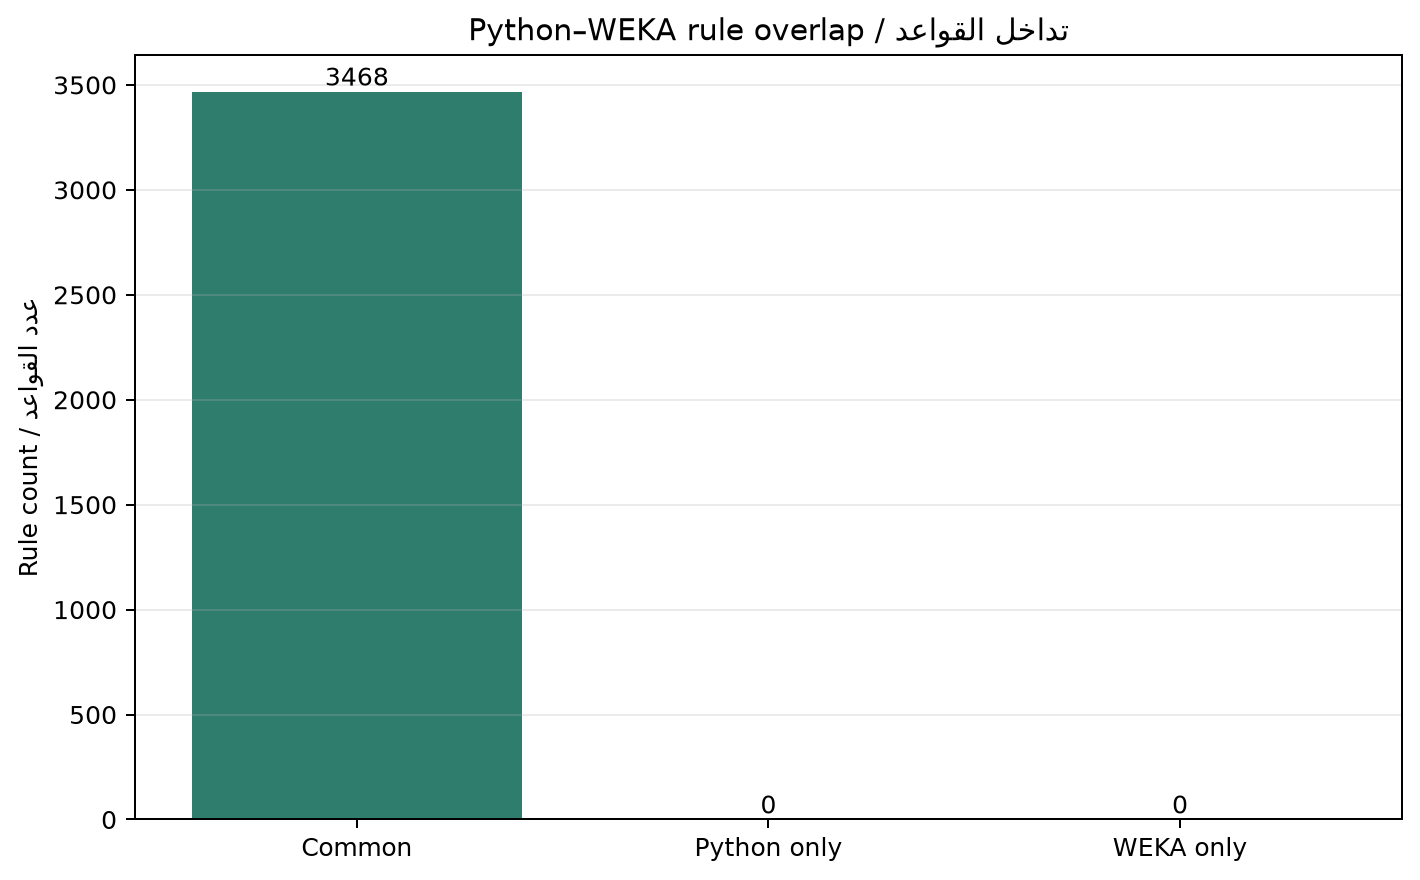

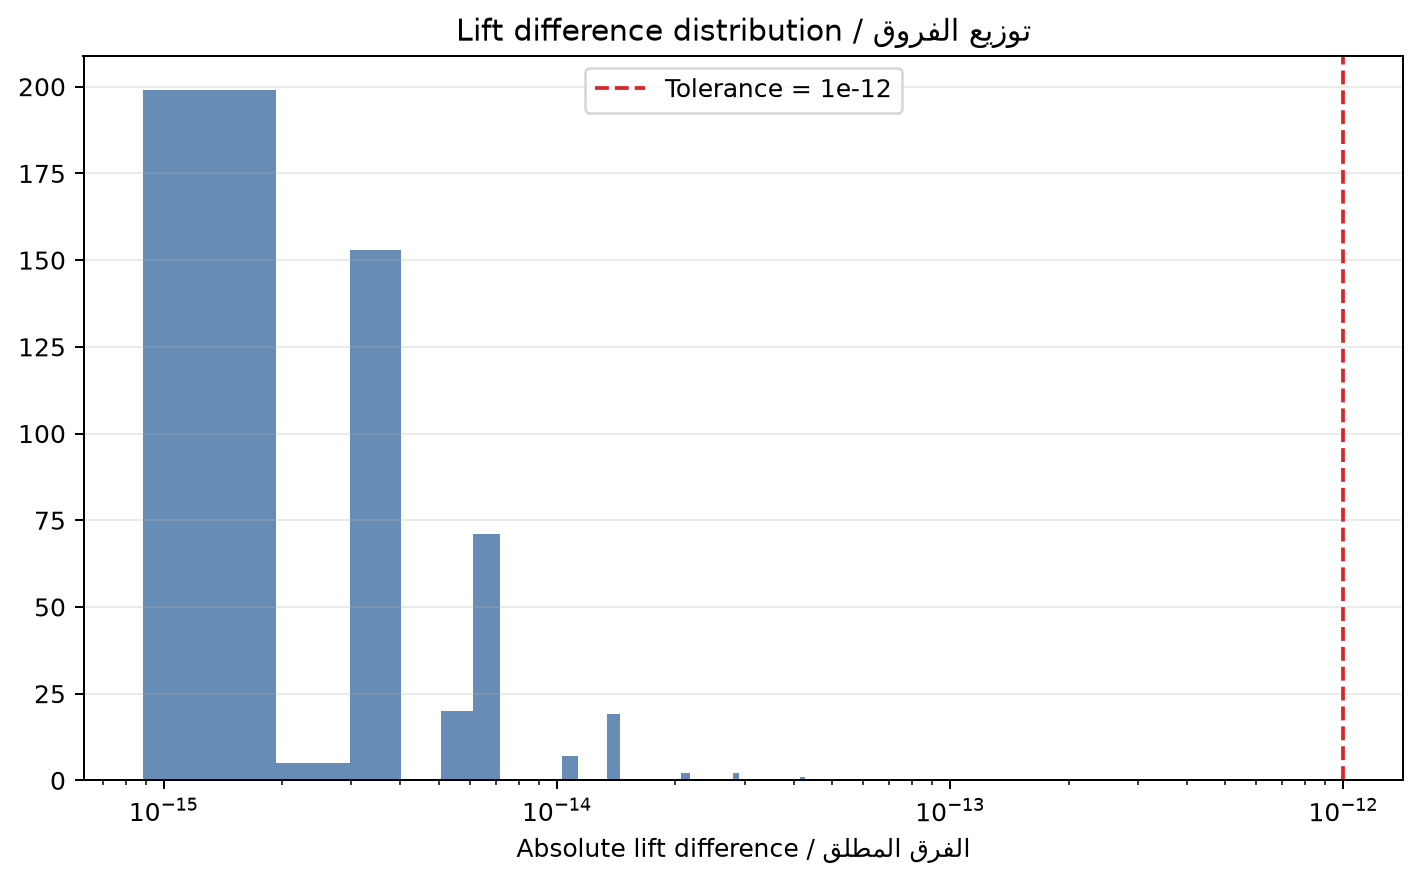

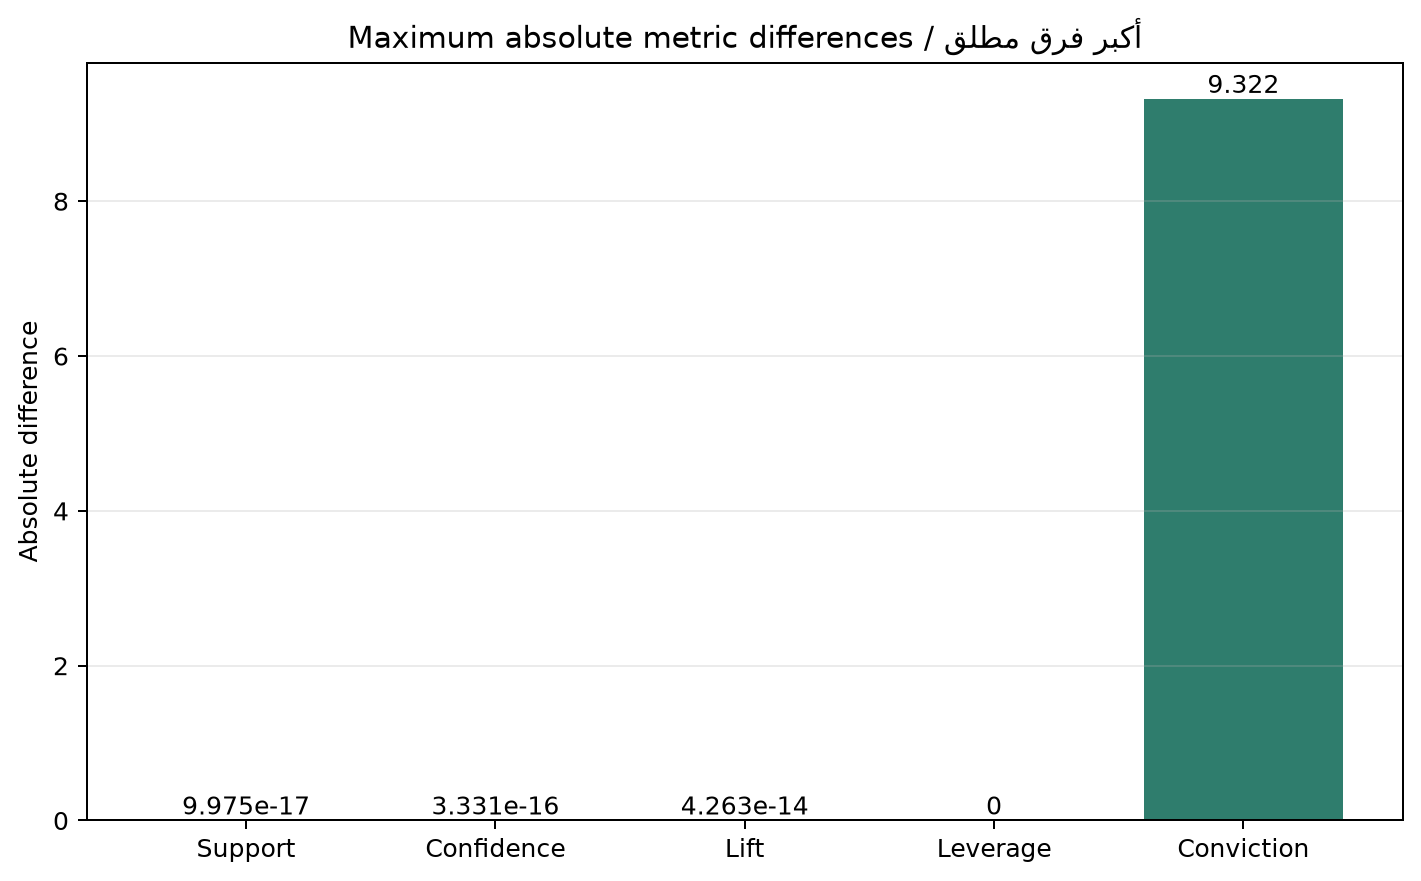

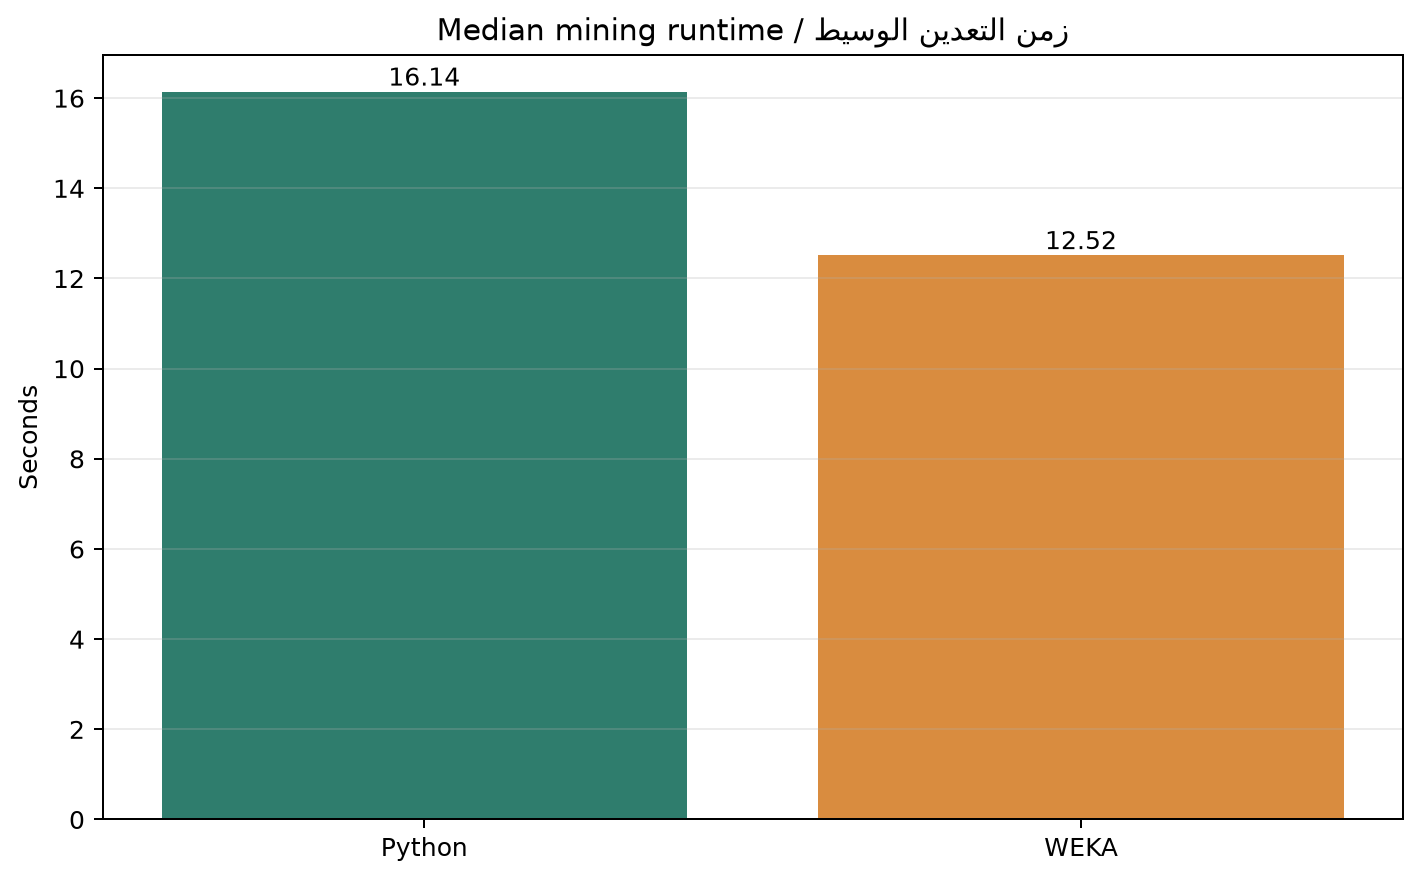

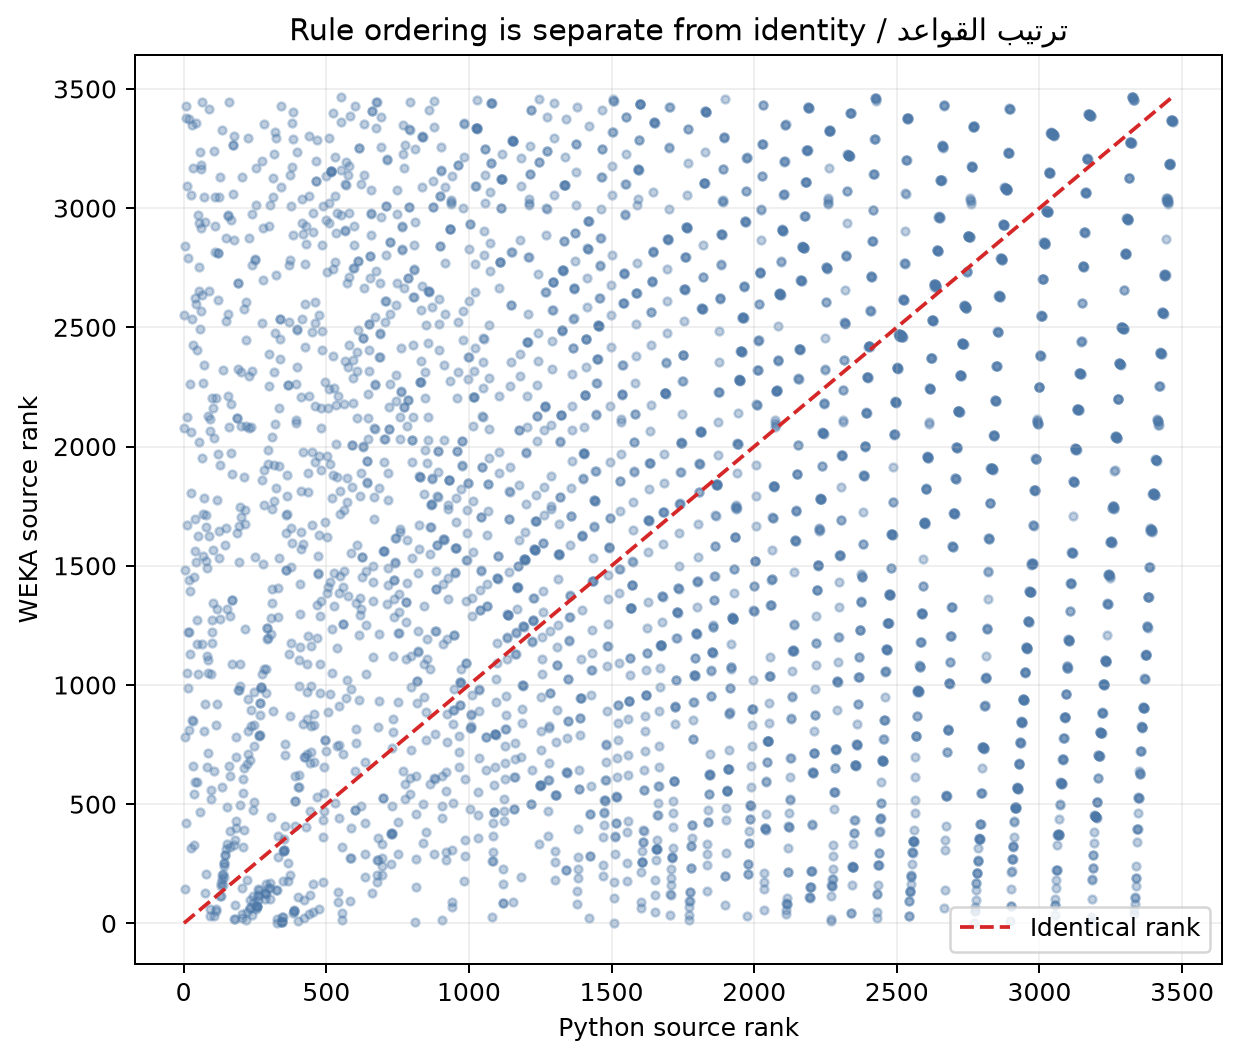

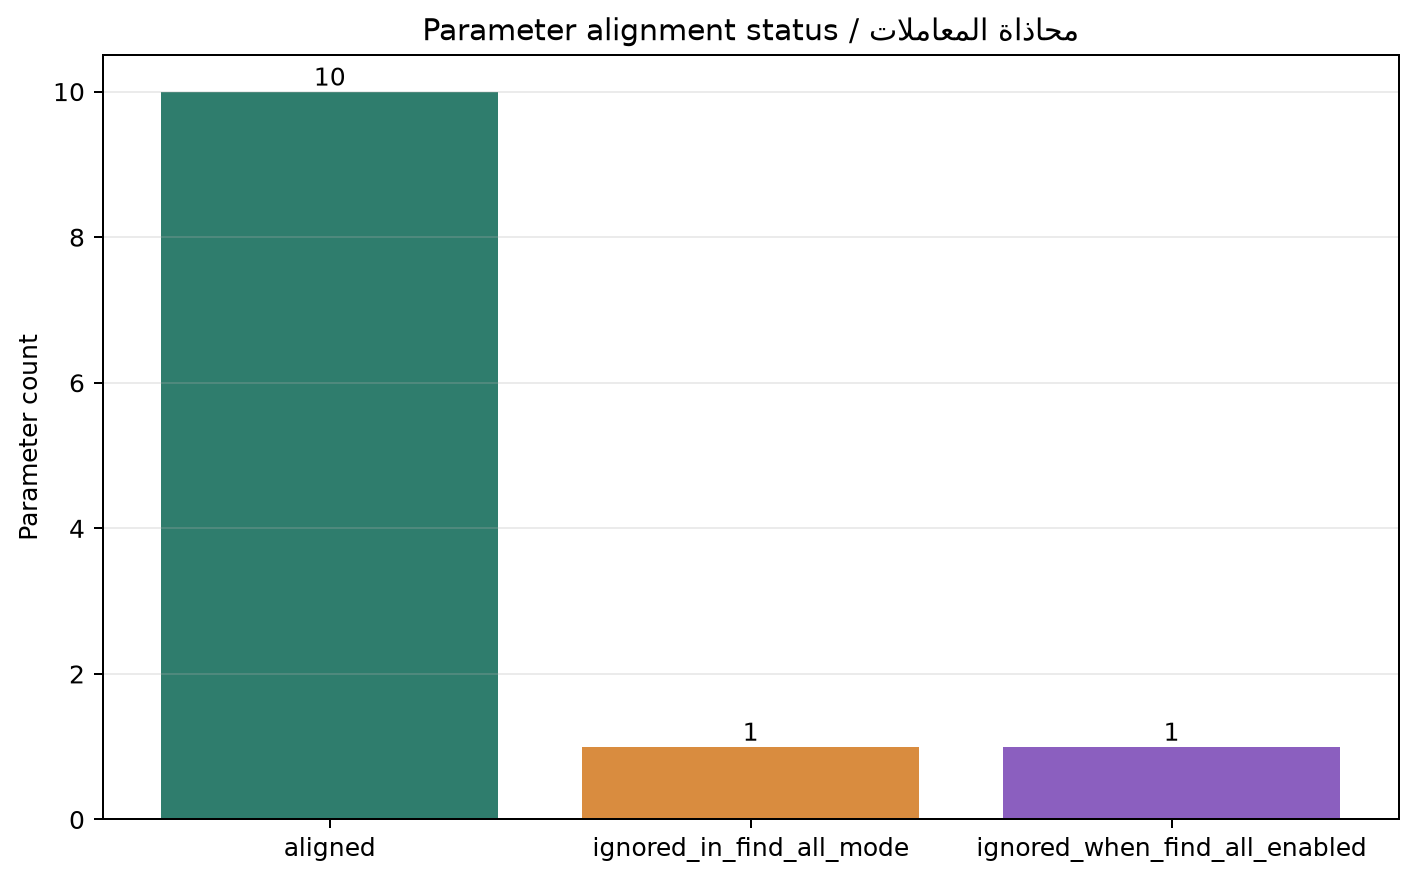

In [8]:
for filename in [
    "python_weka_rule_overlap_summary.png",
    "python_weka_lift_difference_distribution.png",
    "python_weka_maximum_metric_differences.png",
    "python_weka_mining_runtime.png",
    "python_weka_rule_order_difference.png",
    "python_weka_parameter_alignment_summary.png",
]:
    display(Image(filename=str(project_path("outputs", "figures", filename)), width=850))

## WEKA Explorer للعرض الصفي

In [9]:
display(FileLink("docs/notes/WEKA_EXPLORER_GUIDE.md"))
display(FileLink("weka/run_weka_gui.ps1"))
print("Screenshots are a manual presentation task; no screenshots were fabricated.")

D:\University\Data Mining\smartbasket-fpgrowth-lab\docs\notes\WEKA_EXPLORER_GUIDE.md

D:\University\Data Mining\smartbasket-fpgrowth-lab\weka\run_weka_gui.ps1

Screenshots are a manual presentation task; no screenshots were fabricated.


## الخلاصة والقيود

في هذه التجربة تتطابق القواعد المنطقية وsupport counts بالكامل، وتتوافق Support/Confidence/Lift ضمن دقة floating-point وتطابق Leverage تماماً. تختلف Conviction بسبب تعريف WEKA الملساء، ويختلف ترتيب العرض. runtime تجريبي محلي وليس حكماً عاماً. GUI screenshots مؤجلة يدوياً. لم يبدأ التقرير HTML/PDF النهائي أو Phase 7.